In [1]:
import pandas as pd
import csv

In [2]:
def parse_params(params_str):
    params = {}
    for item in params_str.split():
        if '=' in item:
            key, value = item.split('=', 1)
            params[key] = value
    return params

# aggregates results over all parameters except those in params_to_compare
def results_csv_to_df(csv_file, params_to_aggregate=None):
    results = []

    with open(csv_file, newline='') as f:
        reader = csv.DictReader(f, fieldnames=[
            'accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed', 'not_fully_unmasked',
            'checkpoint', 'strategy', 'params'
        ])
        reader.__next__()  # Skip header row
        for row in reader:
            params = parse_params(row['params'])
            row_dict = {
                'accuracy': float(row['accuracy']),
                'correctly_filled_cells': float(row['correctly_filled_cells']),
                'checkpoint': row['checkpoint'],
                'strategy': row['strategy'],
                'nfe': float(row['nfe']),
                'time': float(row['time']),
                'speed': float(row['speed']),
            }
            row_dict.update(params.items())
            results.append(row_dict)
    
    results_df = pd.DataFrame(results)
    print(f"Total rows before aggregation: {len(results_df)}")
    
    # Aggregate the accuracy, correctly_filled_cells, nfe, time, and speed over the rows where all parameters except those in params_to_aggregate are the same
    if params_to_aggregate is not None:
        groupby_cols = [col for col in results_df.columns if col not in params_to_aggregate + ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    else:
        groupby_cols = [col for col in results_df.columns if col not in ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    
    aggregated_df = results_df.groupby(groupby_cols, dropna=False).agg(
        accuracy_mean=pd.NamedAgg(column='accuracy', aggfunc='mean'),
        accuracy_std=pd.NamedAgg(column='accuracy', aggfunc='std'),
        correctly_filled_cells_mean=pd.NamedAgg(column='correctly_filled_cells', aggfunc='mean'),
        correctly_filled_cells_std=pd.NamedAgg(column='correctly_filled_cells', aggfunc='std'),
        nfe=pd.NamedAgg(column='nfe', aggfunc='mean'),
        time=pd.NamedAgg(column='time', aggfunc='mean'),
        speed=pd.NamedAgg(column='speed', aggfunc='mean'),
    ).reset_index()

    print(f"Rows after aggregation: {len(aggregated_df)}")
    return aggregated_df

In [3]:
params_to_aggregate = ['seed']
df = results_csv_to_df('results_independent_strategies.csv', params_to_aggregate=params_to_aggregate)
df

Total rows before aggregation: 9
Rows after aggregation: 9


,checkpoint,strategy,oracle,position_sampling,position_metric,token_sampling,dataset,num_samples,num_denoising_steps,num_self_correction_steps,...,compile_torch,do_beam_search,change_token,accuracy_mean,accuracy_std,correctly_filled_cells_mean,correctly_filled_cells_std,nfe,time,speed
0,checkpoints/gidd_0_2/300_epochs,gidd_independent_positions_decomposed_update_d...,NaN,NaN,NaN,NaN,hard,6400,81,32,...,0,false,change_max,0.1584,NaN,0.6907,NaN,1.25,247.0,25.96
1,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,independent,confident_and_p_denoise,max,hard,6400,81,32,...,0,false,NaN,0.1344,NaN,0.7017,NaN,1.27,238.0,26.91
2,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,independent,margin,max,hard,6400,81,32,...,0,false,NaN,0.0155,NaN,0.3095,NaN,1.27,351.0,18.25
3,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,independent,margin_and_noisy,max,hard,6400,81,32,...,0,false,NaN,0.0172,NaN,0.3172,NaN,1.27,361.0,17.73
4,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,independent,noisy,max,hard,6400,81,32,...,0,false,NaN,0.0002,NaN,0.2249,NaN,1.27,270.0,23.72
5,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,independent,confident_and_p_denoise,max,hard,6400,81,32,...,0,false,NaN,0.1306,NaN,0.7011,NaN,1.27,274.0,23.39
6,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,independent,margin,max,hard,6400,81,32,...,0,false,NaN,0.2759,NaN,0.6937,NaN,1.27,465.0,13.76
7,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,independent,margin_and_noisy,max,hard,6400,81,32,...,0,false,NaN,0.2755,NaN,0.6878,NaN,1.27,451.0,14.20
8,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,independent,noisy,max,hard,6400,81,32,...,0,false,NaN,0.0880,NaN,0.5462,NaN,1.27,414.0,15.44


In [20]:
# Accuracies
grouped_df = df.groupby(['checkpoint', 'strategy', 'oracle', 'position_metric'], dropna=False)['accuracy_mean'].mean().unstack()
grouped_df

position_metric                                                                               confident_and_p_denoise  \
checkpoint                      strategy                                           oracle                               
checkpoints/gidd_0_2/300_epochs gidd_independent_positions_decomposed_update_di... NaN                            NaN   
                                gidd_prob_to_recover_data                          model                       0.1344   
                                                                                   model_EMA                   0.1306   

position_metric                                                                               margin  \
checkpoint                      strategy                                           oracle              
checkpoints/gidd_0_2/300_epochs gidd_independent_positions_decomposed_update_di... NaN           NaN   
                                gidd_prob_to_recover_data                          model      0.0155   
                                                                                   model_EMA  0.2759   

position_metric                                                                               margin_and_noisy  \
checkpoint                      strategy                                           oracle                        
checkpoints/gidd_0_2/300_epochs gidd_independent_positions_decomposed_update_di... NaN                     NaN   
                                gidd_prob_to_recover_data                          model                0.0172   
                                                                                   model_EMA            0.2755   

position_metric                                                                                noisy  \
checkpoint                      strategy                                           oracle              
checkpoints/gidd_0_2/300_epochs gidd_independent_positions_decomposed_update_di... NaN           NaN   
                                gidd_prob_to_recover_data                          model      0.0002   
                                                                                   model_EMA  0.0880   

position_metric                                                                                  NaN  
checkpoint                      strategy                                           oracle             
checkpoints/gidd_0_2/300_epochs gidd_independent_positions_decomposed_update_di... NaN        0.1584  
                                gidd_prob_to_recover_data                          model         NaN  
                                                                                   model_EMA     NaN

In [22]:
# Accuracy, nfe, speed
df[['checkpoint', 'strategy', 'oracle', 'position_metric', 'accuracy_mean', 'nfe', 'speed']]

,checkpoint,strategy,oracle,position_metric,accuracy_mean,nfe,speed
0,checkpoints/gidd_0_2/300_epochs,gidd_independent_positions_decomposed_update_d...,NaN,NaN,0.1584,1.25,25.96
1,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,confident_and_p_denoise,0.1344,1.27,26.91
2,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,margin,0.0155,1.27,18.25
3,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,margin_and_noisy,0.0172,1.27,17.73
4,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model,noisy,0.0002,1.27,23.72
5,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,confident_and_p_denoise,0.1306,1.27,23.39
6,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,margin,0.2759,1.27,13.76
7,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,margin_and_noisy,0.2755,1.27,14.20
8,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,model_EMA,noisy,0.0880,1.27,15.44


In [7]:
import matplotlib.pyplot as plt
def plot_subset(x_axis, subset, category, strategy, strategy_color, marker, linestyle):
    if not subset.empty:
        # Sort by NFE for proper line connection
        subset_sorted = subset.sort_values(x_axis)
        label = f'{strategy[:15]} - {category}'
        plt.plot(subset_sorted[x_axis], subset_sorted['accuracy_mean'], 
                label=label,
                marker=marker,
                color=strategy_color,
                linestyle=linestyle,
                markersize=6, alpha=0.7, linewidth=2)

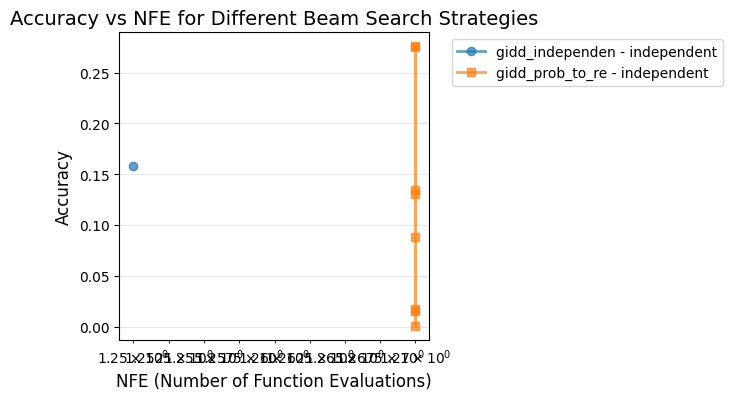

In [8]:
# Plot accuracy vs NFE for each strategy

# Filter data
filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
# filtered_data = df[df['do_beam_search'] == 'false']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            linestyle = '-'
            plot_subset('nfe', subset, category, strategy, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            

plt.xlabel('NFE (Number of Function Evaluations)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs NFE for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
# plt.tight_layout()
plt.show()


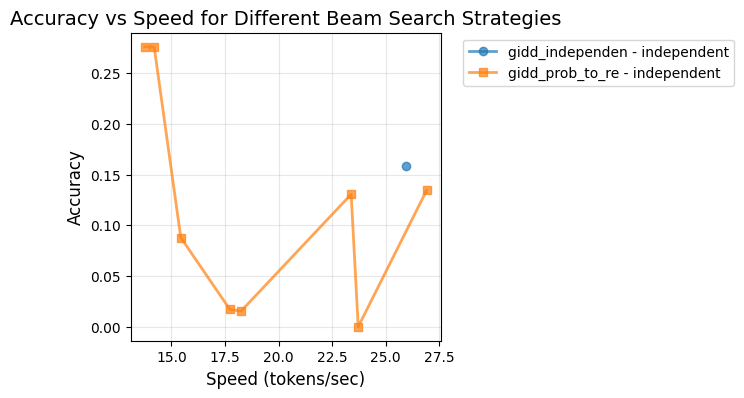

In [14]:
# Plot accuracy vs speed for each strategy with specific filtering
import matplotlib.pyplot as plt

# Filter data based on the specified conditions (same as previous plot)
filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
# filtered_data = df[df['do_beam_search'] == 'false']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            linestyle = '-'
            plot_subset('speed', subset, category, strategy, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            

plt.xlabel('Speed (tokens/sec)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Speed for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xscale('log')
# plt.tight_layout()
plt.show()
